**学习目标**：
1. 将非线性目标、边界、等式和不等式约束转成可执行的 Python 函数；
2. 理解初值、尺度与局部最优，区分"局部最优"与"全局最优"；
3. 独立复核边界、等式/不等式残差与整数/二元条件；
4. 用 `scipy.optimize.milp` 和动态规划求解 0-1 选择问题；
5. 用 PuLP 建模库"按数学公式"快速书写整数规划模型。


# 第一部分：连续非线性规划

目标函数或约束中至少有一项**非线性**、且变量为连续的优化问题。本部分依次讲解：建模约定 → 算法选型 → 非凸性处理 → 参数校准 → 可行性复核 → 敏感性分析。


## 1. 环境与记号约定

连续优化部分采用 `SciPy`。为避免符号混乱，全文统一记号：

- 不等式统一写为 $g_i(x) \le 0$；
- 等式统一写为 $h_j(x) = 0$。

这是便于后续**独立复核**的统一约定（与大多数优化教材一致）。

> ⚠️ **注意**：`minimize(method='SLSQP')` 的旧式字典接口要求不等式函数**返回非负值**（即内部把 $g_i(x)\le0$ 当成 $g_i(x)\ge0$ 处理），与上述记号相反，故代码中会明确标注符号转换，避免写反。

所有代码按顺序运行即可，后面不再重复导入库。


In [17]:
# ===== 导入所需库 =====
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, milp, Bounds, LinearConstraint

# 统一打印格式：5 位有效数字、关闭科学计数法，方便阅读优化结果。
np.set_printoptions(precision=5, suppress=True)
# 固定随机种子，保证参数校准等带随机噪声的示例可复现。
rng = np.random.default_rng(202607)

# 绘图参数：统一画布尺寸，正确显示负号。
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.unicode_minus'] = False

print('NumPy', np.__version__)
import scipy
print('SciPy', scipy.__version__)


NumPy 2.5.1
SciPy 1.18.0


## 2. 从数学模型到函数：统一建模流程

一般非线性规划可写为：

$$\begin{aligned}
\min_x\quad & f(x)\\
\text{s.t.}\quad & g_i(x)\le 0,\quad i=1,\ldots,m,\\
& h_j(x)=0,\quad j=1,\ldots,p,\\
& l_k\le x_k\le u_k.
\end{aligned}$$

**建模三原则**（也是后面所有例子的统一套路）：

1. **变量先行**：先写清每个变量 $x_k$ 的含义、单位和取值范围（这决定了 `bounds` 怎么写）；
2. **分类约束**：把约束分成三类——简单上下界（放 `bounds`）、一般不等式 $g_i(x)\le0$、等式 $h_j(x)=0$。**简单上下界优先放 `bounds`**，不要重复写成一般不等式，这样求解器效率更高、数值更稳；
3. **目标函数返回标量**：`f(x)` 必须返回一个标量（不能返回向量/数组），否则求解器报错。

> **算法选择总览**（后面各节逐一展开）：
> - 无约束 / 仅上下界 → `BFGS` / `L-BFGS-B`；
> - 有一般等式/不等式约束 → `SLSQP`；
> - 非凸、初值难定 → 多起点 + `BFGS`；
> - 变量要求整数/0-1 → `milp`（不能用连续求解器四舍五入）。


## 3. 例 1：凸二次成本最小化（SLSQP 入门）

In [10]:
# ===== 例 1：凸二次成本最小化，用 SLSQP 求解 =====

# --- 模型参数 ---
a = np.array([2.0, 1.5, 1.0])    # 三种生产方式的二次项系数（>0 保证凸性）
b = np.array([4.0, 3.0, 2.0])    # 一次项系数
c = np.array([10.0, 8.0, 6.0])   # 常数项
D = 100.0                        # 总需求

def cost(x):
    """目标函数：总成本 C(x) = sum(a_i*x_i^2 + b_i*x_i + c_i)。
    输入: 产量向量 x (长度 3)
    输出: 总成本标量"""
    return np.sum(a * x**2 + b * x + c)

# --- 约束定义 ---
# SLSQP 的 ineq 约束必须返回 >= 0，因此总产量 >= D 应写成 D - sum(x)（>= 0）。
# 这里是等式约束 sum(x) = D，写成 fun = sum(x) - D（= 0）。
constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - D}]
bounds = [(0.0, None)] * 3       # 三个变量都 >= 0（简单下界，放 bounds 而非约束）
x0 = np.array([30.0, 30.0, 40.0])  # 初值：任意可行解附近即可

# --- 求解 ---
# minimize 通用接口：method='SLSQP' 支持 bounds + constraints。
# options: ftol 控制收敛精度（越小越精确），maxiter 最大迭代次数。
res_cost = minimize(cost, x0, method='SLSQP', bounds=bounds, constraints=constraints,
                    options={'ftol': 1e-12, 'maxiter': 500})

# --- 输出与复核 ---
print('success:', res_cost.success)          # 是否成功收敛
print('message:', res_cost.message)          # 求解器返回信息
print('x*:', res_cost.x)                     # 最优产量
print('C(x*):', res_cost.fun)                # 最小总成本
print('sum(x*):', res_cost.x.sum())          # 复核等式约束：应精确等于 D
print('marginal costs:', 2 * a * res_cost.x + b)  # 各方式边际成本：KKT 条件下应相等


success: True
message: Optimization terminated successfully
x*: [22.76923 30.69231 46.53846]
C(x*): 4915.961538461557
sum(x*): 100.0
marginal costs: [95.07693 95.07692 95.07692]


### 一阶条件的经济解释（KKT 条件复核）

对于正产量变量 $x_i>0$（下界约束不起作用），KKT 条件给出

$$2a_ix_i+b_i+\lambda=0 \iff 2a_ix_i+b_i = -\lambda.$$

即**最优解中各生产方式的边际成本应当相等**（都等于 $-\lambda$，其中 $\lambda$ 是等式约束 $D$ 的拉格朗日乘子）。

> 上一单元格最后一行直接输出 `marginal costs`，你应看到三个值**几乎完全相等**。这既是对数值解的解释，也是一种**模型层面的复核**：如果边际成本不相等，说明求解未收敛或模型写错。

边际成本相等正是"资源在不同生产方式之间最优分配"的经济学直觉：哪条边际成本低，就该多生产它，直到各条边际成本拉平。


## 4. 非凸性、初值与局部最优

x0=-2.0 -> x*=-1.024120, f(x*)=-0.202440, success=True
x0=-0.2 -> x*=-1.024121, f(x*)=-0.202440, success=True
x0= 0.2 -> x*= 0.973994, f(x*)= 0.197434, success=True
x0= 2.0 -> x*= 0.973994, f(x*)= 0.197434, success=True


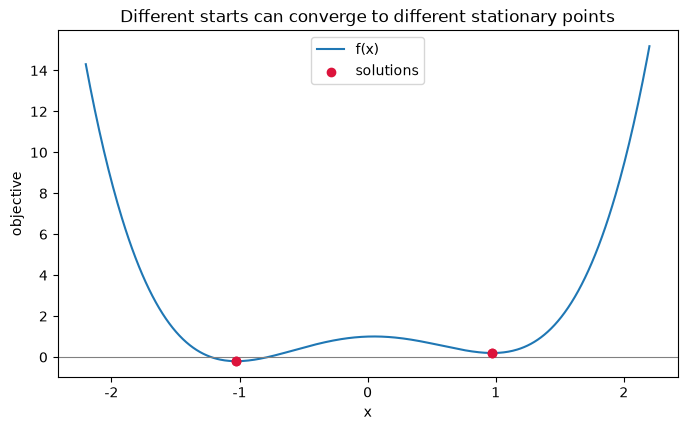

In [11]:
# ===== 非凸函数的多起点演示：初值决定收敛结果 =====

def nonconvex_obj(x):
    """非凸测试函数 f(x) = (x^2 - 1)^2 + 0.2x，有两个极小点。
    输入: x 为单元素数组
    输出: 目标值标量"""
    return (x[0]**2 - 1)**2 + 0.2 * x[0]

# --- 多起点策略：从 4 个不同初值分别求解 ---
# 同一个函数、同一个求解器，仅初值不同。
starts = [-2.0, -0.2, 0.2, 2.0]
runs = [minimize(nonconvex_obj, x0=np.array([s]), method='BFGS') for s in starts]

# 观察：部分初值收敛到左边的极小点，部分收敛到右边的极小点。
for s, run in zip(starts, runs):
    print(f'x0={s:>4.1f} -> x*={run.x[0]: .6f}, f(x*)={run.fun: .6f}, success={run.success}')

# --- 可视化：函数曲线 + 各初值的收敛点 ---
# 网格足够密，画出函数真实形状。
grid = np.linspace(-2.2, 2.2, 500)
plt.plot(grid, (grid**2 - 1)**2 + 0.2 * grid, label='f(x)')
# 红色散点标记 4 个初值各自收敛到的位置，可见"落在不同谷底"。
plt.scatter([r.x[0] for r in runs], [r.fun for r in runs], color='crimson', zorder=3, label='solutions')
plt.axhline(0, color='gray', linewidth=0.8)
plt.legend(); plt.xlabel('x'); plt.ylabel('objective'); plt.title('Different starts can converge to different stationary points');
plt.show()


**实践建议（竞赛中务必执行）**：

1. **记录初值来源**：论文中说明初值是如何选取的（经验值/均匀网格/随机采样），保证可复现；
2. **多起点稳健性检查**：对非凸问题至少用 5~10 个初值（网格或随机）求解，取目标值最小者；若所有起点收敛到同一解，可信度大幅提升；
3. **证明凸性以说明全局最优**：若能证明目标凸、可行域凸，则"局部最优 = 全局最优"可以直接写进论文，避免多起点的麻烦；
4. **怀疑求解器先怀疑模型**：结果不合理时，优先检查目标函数与约束是否写对（符号、维度），而不是盲目换求解器。


## 5. 非线性参数校准：带边界的最小二乘

success: True
theta_hat [a, b, c]: [2.89922 0.32076 0.58076]
SSE: 0.9495703753994823
max |residual|: 0.3584851629224719


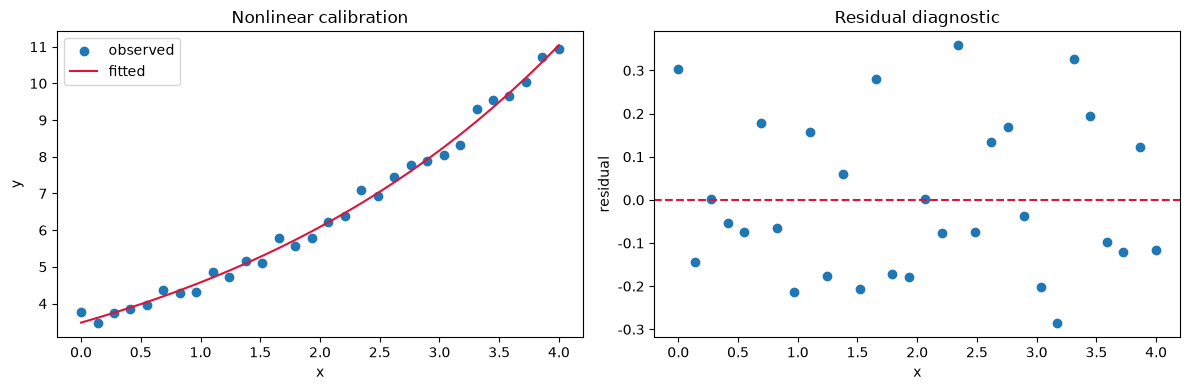

In [12]:
# ===== 非线性参数校准：L-BFGS-B 带边界最小二乘 =====

# --- 生成模拟数据（真实参数 theta_true + 高斯噪声） ---
x_data = np.linspace(0, 4, 30)                      # 自变量：30 个均匀采样点
theta_true = np.array([2.4, 0.35, 1.2])             # 真实参数 [a, b, c]（仅用于验证）
y_data = theta_true[0] * np.exp(theta_true[1] * x_data) + theta_true[2] + rng.normal(0, 0.18, x_data.size)

def exp_model(x, theta):
    """指数模型 y = a*exp(b*x) + c。
    输入: 自变量 x, 参数 theta = [a, b, c]
    输出: 模型预测值"""
    a_, b_, c_ = theta
    return a_ * np.exp(b_ * x) + c_

def sse(theta):
    """目标函数：残差平方和 S(theta) = sum[(y_i - f(x_i;theta))^2]。
    输入: 参数 theta
    输出: SSE 标量"""
    residual = y_data - exp_model(x_data, theta)
    return np.sum(residual**2)

# --- 初值与边界 ---
theta0 = np.array([1.0, 0.1, 0.0])            # 初值：a 从 1 起，b 从 0.1 起，c 从 0 起
theta_bounds = [(0.0, 10.0), (-1.0, 1.0), (-5.0, 5.0)]   # 先验边界

# --- 求解：L-BFGS-B 只接受 bounds，不接受一般约束 ---
res_fit = minimize(sse, theta0, method='L-BFGS-B', bounds=theta_bounds)
theta_hat = res_fit.x                          # 最优参数
residuals = y_data - exp_model(x_data, theta_hat)  # 逐点残差（用于残差图）

# --- 输出 ---
print('success:', res_fit.success)
print('theta_hat [a, b, c]:', theta_hat)
print('SSE:', res_fit.fun)
print('max |residual|:', np.max(np.abs(residuals)))

# --- 可视化：拟合效果 + 残差诊断 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(x_data, y_data, label='observed')            # 观测点
axes[0].plot(x_data, exp_model(x_data, theta_hat), color='crimson', label='fitted')  # 拟合曲线
axes[0].set(xlabel='x', ylabel='y', title='Nonlinear calibration')
axes[0].legend()
axes[1].axhline(0, color='crimson', linestyle='--')          # 零线参考
axes[1].scatter(x_data, residuals)                           # 残差点：应围绕 0 随机分布
axes[1].set(xlabel='x', ylabel='residual', title='Residual diagnostic')
plt.tight_layout(); plt.show()


### 残差图怎么看？（诊断模型而非求解器）

残差图不能单独证明模型正确，但应检查：

1. **是否围绕 0 随机分布**：若是，说明模型形式基本合理；
2. **是否存在明显趋势**：若残差随 x 呈现曲线/趋势，说明模型形式选择不当（例如该用 $a\exp(bx)+c$ 却用了线性模型）；
3. **是否存在异方差**：若残差"喇叭形"发散（x 越大误差越大），说明数据尺度不均或需要加权。

> 若出现系统性结构，**优先考虑模型形式、数据质量或遗漏变量**，而不是只调整求解器参数——求解器不会修复错误模型。


## 6. 可行性复核：不要只看 `success`

In [13]:
# ===== 通用可行性复核函数（可复用到任何优化问题） =====

def audit_solution(x, bounds, ineq_leq=(), eq=(), integer_idx=(), binary_idx=(), tol=1e-7):
    """复核约束函数：不等式按 g(x) <= 0 形式，等式按 h(x) = 0 形式。
    输入:
        x           解向量
        bounds      边界列表 [(lo, hi), ...]，None 表示无界
        ineq_leq    不等式函数列表（每个返回标量或数组，需满足 g(x) <= 0）
        eq          等式函数列表（每个返回标量或数组，需满足 h(x) = 0）
        integer_idx 要求为整数的变量索引元组
        binary_idx  要求为 0-1 的变量索引元组
        tol         可接受的最大违约量（默认 1e-7）
    输出:
        report 字典，含五类违约量、max_violation 与 feasible 布尔值
    """
    x = np.asarray(x, dtype=float)
    # 1) 边界违约：拆出下界/上界数组，计算越界最大值。
    lower = np.array([-np.inf if lo is None else lo for lo, _ in bounds], dtype=float)
    upper = np.array([ np.inf if hi is None else hi for _, hi in bounds], dtype=float)
    bound_violation = max(np.max(lower - x), np.max(x - upper), 0.0)
    # 2) 一般不等式违约：把各 g(x) 拼起来，取 > 0 的最大值。
    ineq_values = np.concatenate([np.atleast_1d(g(x)) for g in ineq_leq]) if ineq_leq else np.array([])
    ineq_violation = max(0.0, np.max(ineq_values)) if ineq_values.size else 0.0
    # 3) 等式违约：|h(x)| 的最大值。
    eq_values = np.concatenate([np.atleast_1d(h(x)) for h in eq]) if eq else np.array([])
    eq_violation = np.max(np.abs(eq_values)) if eq_values.size else 0.0
    # 4) 整数违约：与最近整数的最大偏差。
    int_violation = np.max(np.abs(x[list(integer_idx)] - np.round(x[list(integer_idx)]))) if integer_idx else 0.0
    # 5) 二元违约：整数偏差与超出 [0,1] 范围的较大者。
    bin_violation = max(np.max(np.abs(x[list(binary_idx)] - np.round(x[list(binary_idx)]))),
                        np.max(np.maximum(-x[list(binary_idx)], x[list(binary_idx)] - 1))) if binary_idx else 0.0
    # 汇总：最大违约量决定是否可行。
    report = {'bound': bound_violation, 'ineq': ineq_violation, 'eq': eq_violation,
              'integer': int_violation, 'binary': bin_violation}
    report['max_violation'] = max(report.values())
    report['feasible'] = report['max_violation'] <= tol
    return report

# --- 应用到例 1 的结果：复核 x1+x2+x3 = 100 与 x_i >= 0 ---
cost_audit = audit_solution(
    res_cost.x, bounds=bounds,
    eq=[lambda x: np.sum(x) - D]     # 等式约束：总产量 = D
)
print(cost_audit)


{'bound': 0.0, 'ineq': 0.0, 'eq': np.float64(0.0), 'integer': 0.0, 'binary': 0.0, 'max_violation': 0.0, 'feasible': True}


## 7. 敏感性分析：需求变化是否改变结论？

D=   80, x*=[18.15385 24.53846 37.30769], C*=3199.038
D=  100, x*=[22.76923 30.69231 46.53846], C*=4915.962
D=  120, x*=[27.38461 36.84615 55.76923], C*=7002.115


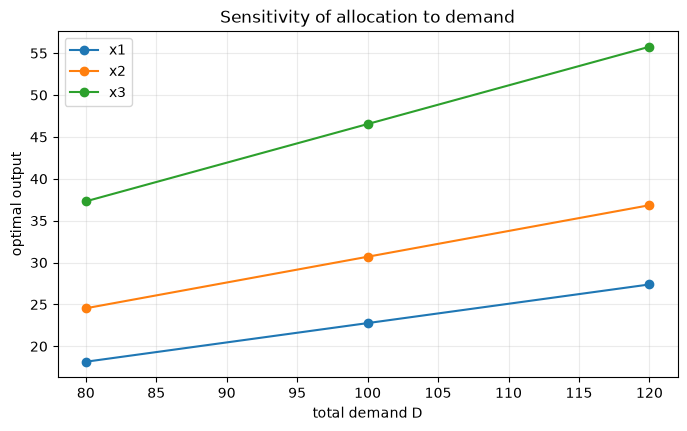

In [14]:
# ===== 敏感性分析：总需求 D 变化对最优解的影响 =====

def solve_allocation(demand):
    """在给定总需求 demand 下重解成本最小化问题。
    输入: demand 总需求
    输出: (最优产量, 最小成本, 最大违约量)"""
    result = minimize(cost, np.repeat(demand / 3, 3), method='SLSQP',
                      bounds=bounds, constraints=[{'type': 'eq', 'fun': lambda x: x.sum() - demand}])
    # 每次都做可行性复核，确保不是"数值上可行但约束违约"的解。
    audit = audit_solution(result.x, bounds, eq=[lambda x: x.sum() - demand])
    return result.x, result.fun, audit['max_violation']

# --- 扫描需求：80 / 100 / 120 ---
demands = np.array([80.0, 100.0, 120.0])
solutions = np.array([solve_allocation(d)[0] for d in demands])
objectives = np.array([solve_allocation(d)[1] for d in demands])

# 输出每个需求下的最优产量与成本，观察方案结构是否变化。
for demand, solution, objective in zip(demands, solutions, objectives):
    print(f'D={demand:>5.0f}, x*={solution}, C*={objective:.3f}')

# 绘制三条产量曲线随需求变化的趋势，直观看出各生产方式占比变化。
plt.plot(demands, solutions, marker='o')
plt.xlabel('total demand D'); plt.ylabel('optimal output'); plt.title('Sensitivity of allocation to demand')
plt.legend(['x1', 'x2', 'x3']); plt.grid(alpha=0.25); plt.show()


# 第二部分：整数规划与 0-1 变量

变量要求为**整数**（含 0-1 二元变量）的优化问题。整数问题必须用整数求解器（`milp`）或专用算法（动态规划），不能把连续解简单四舍五入。本部分通过"项目选择（0-1 背包）"讲解两种求解与交叉验证方法。


## 8. 整数与 0-1 变量（整数规划）

In [18]:
# ===== 项目选择问题（0-1 背包），用 milp 求解 =====

# --- 模型数据：6 个候选项目 ---
names = np.array(['A', 'B', 'C', 'D', 'E', 'F'])
values = np.array([12, 10, 20, 15, 8, 9], dtype=float)   # 各项目收益
weights = np.array([2, 3, 7, 6, 4, 5], dtype=float)      # 各项目成本
budget = 14.0                                            # 总预算上限

# --- milp 建模 ---
# milp 求解最小化问题，因此最大化收益 = 最小化 -values。
milp_result = milp(
    c=-values,                                    # 目标系数（取负）
    integrality=np.ones(len(values)),             # 全部变量要求为整数
    bounds=Bounds(np.zeros(len(values)), np.ones(len(values))),  # 0 <= z_i <= 1
    constraints=LinearConstraint(weights, -np.inf, budget),      # 预算约束：w·z <= budget
)
# 整数求解器返回浮点数，取整为 0/1 使用（此时取整是安全的，因已保证整数性）。
z = np.rint(milp_result.x).astype(int)

# --- 输出与复核 ---
print('success:', milp_result.success)
print('selected:', names[z == 1].tolist())   # 被选中的项目
print('z:', z)
print('total weight:', weights @ z, '<=', budget)   # 复核预算约束
print('total value:', values @ z)                  # 总收益
# 用通用复核函数检查整数性/二元性/预算约束。
print(audit_solution(z, [(0, 1)] * len(z),
                     ineq_leq=[lambda x: weights @ x - budget],
                     integer_idx=tuple(range(len(z))), binary_idx=tuple(range(len(z)))))


success: True
selected: ['A', 'B', 'C']
z: [1 1 1 0 0 0]
total weight: 12.0 <= 14.0
total value: 42.0
{'bound': np.float64(0.0), 'ineq': 0.0, 'eq': 0.0, 'integer': np.float64(0.0), 'binary': np.float64(0.0), 'max_violation': np.float64(0.0), 'feasible': np.True_}


## 9. 用动态规划交叉验证 0-1 背包

In [19]:
# ===== 动态规划求解 0-1 背包，与 milp 交叉验证 =====

def knapsack_dp(values, weights, capacity):
    """0-1 背包动态规划（要求重量与容量为整数）。
    输入: values 价值数组, weights 重量数组(整数), capacity 容量(整数)
    输出: (choice 0/1 选择向量, 最大总价值, dp 完整状态表)"""
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=int)
    n = len(values)
    # dp[i, w]: 前 i 件物品、容量 w 的最大价值；take[i, w]: 是否取了第 i 件。
    dp = np.zeros((n + 1, capacity + 1))
    take = np.zeros((n + 1, capacity + 1), dtype=bool)
    # 自底向上填表：外层遍历物品，内层遍历容量。
    for i in range(1, n + 1):
        for w in range(capacity + 1):
            dp[i, w] = dp[i - 1, w]                    # 方案1：不取第 i 件
            if weights[i - 1] <= w:                    # 装得下才考虑方案2
                candidate = dp[i - 1, w - weights[i - 1]] + values[i - 1]  # 方案2：取第 i 件
                if candidate > dp[i, w]:
                    dp[i, w] = candidate
                    take[i, w] = True
    # 回溯：从最后一个状态倒推，还原选择了哪些物品。
    choice = np.zeros(n, dtype=int)
    w = capacity
    for i in range(n, 0, -1):
        if take[i, w]:
            choice[i - 1] = 1
            w -= weights[i - 1]
    return choice, dp[n, capacity], dp

# --- 用与 milp 相同的数据求解 ---
z_dp, value_dp, dp_table = knapsack_dp(values, weights.astype(int), int(budget))
print('DP selected:', names[z_dp == 1].tolist())
print('DP value:', value_dp)

# --- 交叉验证：两种独立算法结果必须一致 ---
assert np.isclose(value_dp, values @ z), 'MILP and DP should agree on this instance'
print('Cross-check passed: MILP and DP give the same objective value.')


DP selected: ['A', 'B', 'C']
DP value: 42.0
Cross-check passed: MILP and DP give the same objective value.


## 10. PuLP 建模库：用"数学公式"写整数规划

前几节用 `milp` 求解整数规划时，需要把模型手动转换成矩阵形式（`c`、`integrality`、`Bounds`、`LinearConstraint`）。当变量和约束很多时，这种写法**容易错位、可读性差**。

**PuLP** 是一个建模器（Modeling Language）级别的库：允许直接用变量名和 `+`、`<=`、`==` 运算符书写模型，**代码即公式**，与数学表达式几乎一一对应。

**建模三步法**（与数学建模写法一致）：

1. **定义问题**：`LpProblem("名称", LpMaximize / LpMinimize)`；
2. **声明变量**：`LpVariable(name, lowBound=..., cat=...)`，`cat` 可选 `LpContinuous`（连续）/ `LpInteger`（整数）/ `LpBinary`（0-1）；
3. **添加目标与约束**：用 `prob += 表达式` 直接写入，支持 `<=`、`>=`、`==`。

**与 `milp` 的对比**：

| 对比项 | `scipy.optimize.milp` | **PuLP** |
|--------|----------------------|----------|
| 建模方式 | 手动拼矩阵（c / integrality / Bounds） | 直接写数学表达式 |
| 可读性 | 变量多时容易错位 | 与公式一一对应，不易出错 |
| 0-1 变量 | `Bounds(0,1) + integrality=1` | `cat=LpBinary` 一行搞定 |
| 求解器 | 固定 HiGHS | 默认 CBC，可换 Gurobi/CPLEX/HiGHS |
| 整数约束方向 | 只支持 ≤ 形式需手动转换 | `>=`、`<=`、`==` 直接写 |

**优点**：可读性强（论文/答辩可直接读代码）；变量类型声明直观；可切换求解器。
**缺点**：需要 `pip install pulp`；建模有少量额外开销（毫秒级，可忽略）；小规模问题上比直接调 `milp` 略慢。
**适用场景**：变量多、约束杂的竞赛模型（运输、选址、排产、背包）；需要整数/0-1 变量时首选。


In [20]:
# ===== PuLP 求解 0-1 背包：同一模型，第三种解法（与前文 milp/DP 交叉验证） =====
# 若未安装 pulp，先运行: !pip install pulp

import pulp

# 1. 定义问题：最大化总价值。
prob = pulp.LpProblem("项目选择", pulp.LpMaximize)

# 2. 声明 0-1 决策变量：x[i] = 1 表示选择项目 i。
#    cat=pulp.LpBinary 即 0-1 变量，比 milp 的 Bounds+integrality 更直观。
x = [pulp.LpVariable(f"x{i}", cat=pulp.LpBinary) for i in range(len(values))]

# 3. 目标函数：总收益最大，用 lpSum 累加表达式。
prob += pulp.lpSum(values[i] * x[i] for i in range(len(values)))

# 4. 约束：预算约束 sum(w_i * x_i) <= budget，直接写数学表达式。
prob += pulp.lpSum(weights[i] * x[i] for i in range(len(values))) <= budget

# 5. 求解：默认 CBC 求解器（若机器上有 Gurobi/CPLEX，可指定 solver 参数）。
status = prob.solve()

# 6. 读取结果：varValue 给出每个变量的取值。
z_pulp = np.array([int(x[i].varValue) for i in range(len(values))])

print('求解状态:', pulp.LpStatus[status])          # 'Optimal' 表示找到最优解
print('selected:', names[z_pulp == 1].tolist())   # 被选中的项目
print('total weight:', weights @ z_pulp, '<=', budget)
print('total value:', values @ z_pulp)            # 应等于 pulp.value(prob.objective)

# --- 三种算法交叉验证：milp、DP、PuLP 必须给出相同结果 ---
assert np.isclose(values @ z_pulp, values @ z), 'PuLP and MILP should agree'
assert np.isclose(values @ z_pulp, value_dp), 'PuLP and DP should agree'
print('Cross-check passed: MILP, DP and PuLP give the same objective value.')


求解状态: Optimal
selected: ['A', 'B', 'C']
total weight: 12.0 <= 14.0
total value: 42.0
Cross-check passed: MILP, DP and PuLP give the same objective value.


# 第三部分：交付清单与练习

把前面所有工具串成一套可复用的实战流程，并用三道练习题检验掌握程度。


## 11. 实战交付前清单（逐项自检）

## 12. 课堂练习

<details><summary>练习 2 参考解（点击展开）</summary>

互斥约束可以和预算约束一起传入 `milp`，只需把两条线性约束纵向堆叠成一个约束矩阵：

```python
A = np.vstack([weights, [0, 0, 1, 1, 0, 0]])   # 第 1 行：预算；第 2 行：z_C + z_D <= 1
constraints = LinearConstraint(A, [-np.inf, -np.inf], [budget, 1])
result = milp(c=-values, integrality=np.ones(6),
              bounds=Bounds(np.zeros(6), np.ones(6)), constraints=constraints)
```

- `weights` 是第 1 行：预算约束 $\sum w_iz_i \le budget$；
- `[0,0,1,1,0,0]` 是第 2 行：只有 C、D 两个项目系数为 1，即 $z_C+z_D\le 1$；
- 上界数组 `[budget, 1]` 分别对应两条约束的右端项。

复核时除预算外，还应把 $z_C+z_D-1$ 作为 $g(z)\le0$ 传给 `audit_solution`：

```python
# C 是索引 2，D 是索引 3
audit = audit_solution(result.x, [(0, 1)] * 6,
                       ineq_leq=[lambda x: weights @ x - budget,
                                 lambda x: x[2] + x[3] - 1],
                       integer_idx=tuple(range(6)), binary_idx=tuple(range(6)))
print(audit)
```
</details>
